# From Earth to Plate - Notebook 01: Food product emissions

**Maurice Baz & Dominika Bondyra** - JH Data Patterns and Representations, final project.

This notebook builds the per-food emissions story of the deck: how large the gap between
foods is, and how the picture changes when the comparison moves to a different
functional unit (per 100 g of protein).

**Slide-to-figure mapping**

| Deck slide | Figure | File |
|---|---|---|
| Slide 2 (hook) | Beef vs peas, land-to-retail per kg | `figures/fig_slide02_beef_vs_peas.png` |
| Slide 4 (per-kg spread) | 16 selected foods, land-to-retail per kg | `figures/fig_slide04_perkg_key_foods.png` |
| Slide 5 (per protein) | 20 protein sources, per 100 g protein | `figures/fig_slide05_per_protein.png` |
| Appendix | All 43 foods, land-to-retail per kg | `figures/fig_appendix_perkg_all43.png` |
| Appendix | Rank flip: global-average per kg vs per protein | `figures/fig_appendix_slide05_rank_flip.png` |

## Data

**Sources**

1. `data/Food_Product_Emissions.csv` - 43 food products with supply-chain stage
   emissions (Land Use Change, Feed, Farm, Processing, Transport, Packaging, Retail),
   in **kg CO2e per kg of food**. From Poore & Nemecek (2018), *Science*, processed by
   Our World in Data. No missing values.
2. `data/ghg-per-protein-poore.csv` - 32 foods with emissions in
   **kg CO2e per 100 g of protein** (reference year 2010, same underlying study).
   Naming quirk: this file says "Prawns (farmed)" where the per-kg file says
   "Shrimps (farmed)" - the same product; we map the names when joining.

**Basis decision.** The per-kg file carries two totals, and we keep them as two named
constants throughout:

- `STAGE_TOTAL` = "Total from Land to Retail" - the exact sum of the seven
  supply-chain stage columns in the file (asserted below). This is the basis whenever
  the seven stage columns are analyzed or displayed.
- `OWID_PERKG` = "Total Global Average GHG Emissions per kg" - a companion
  global-average per-kg series provided by the same source file. The repository does
  not document the exact scope difference between the two totals, so we never treat
  them as additive or interchangeable; `OWID_PERKG` appears only as a companion series
  (for example next to the OWID per-protein data in the appendix rank flip).

**A detail worth knowing:** "Land Use Change" is *negative* for some foods
(Nuts -2.05, Olive Oil -0.38, Citrus Fruit -0.15, and a few others). These negative
values are source-specific accounting credits under the source methodology; the
repository carries no documentation of the mechanism behind them, so we do not attach
a causal story. Mechanically, the credit is why Nuts land at the very bottom of the
land-to-retail ranking.

**Category labels** (used across all four notebooks): 10 foods are **animal-based**
(Beef beef herd, Beef dairy herd, Cheese, Eggs, Fish (farmed), Lamb & Mutton, Milk,
Pig Meat, Poultry Meat, Shrimps (farmed)); the other 33 are **plant-based**.
Animal-based is always drawn in blue, plant-based always in green.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Paths resolve whether the notebook runs from the repo root or from notebooks/
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA, FIGS = ROOT / 'data', ROOT / 'figures'
FIGS.mkdir(exist_ok=True)

# ---- house style (shared across all four notebooks) ----
SURFACE = '#fcfcfb'   # figure + axes surface
INK     = '#0b0b0b'   # primary ink (titles)
SEC     = '#52514e'   # secondary ink (subtitles, value labels)
MUTED   = '#898781'   # muted (ticks, axis titles, captions)
GRID    = '#e1e0d9'   # hairline grid
AXIS    = '#c3c2b7'   # baseline / axis line
BLUE    = '#2a78d6'   # semantic: animal-based
GREEN   = '#008300'   # semantic: plant-based

mpl.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Segoe UI', 'DejaVu Sans'],
    'text.color': INK,
    'axes.edgecolor': AXIS,
    'axes.labelcolor': MUTED,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'xtick.labelcolor': MUTED,
    'ytick.labelcolor': MUTED,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
})

ANIMAL = {'Beef (beef herd)', 'Beef (dairy herd)', 'Cheese', 'Eggs', 'Fish (farmed)',
          'Lamb & Mutton', 'Milk', 'Pig Meat', 'Poultry Meat', 'Shrimps (farmed)'}


def fmt(v):
    """Value label: two decimals below 1, one decimal above (units live in the subtitle)."""
    return f'{v:,.2f}' if v < 1 else f'{v:,.1f}'


def style_axes(ax):
    """Horizontal-bar house style: grid along the value axis only, no box,
    baseline and axis line in the muted axis color, no tick marks."""
    ax.grid(axis='x')
    ax.grid(axis='y', visible=False)
    ax.spines['left'].set_color(AXIS)
    ax.spines['bottom'].set_color(AXIS)
    ax.tick_params(length=0)


def add_titles(ax, title, subtitle, source, source_pts=-34):
    """Left-aligned takeaway title (primary ink), measure+unit subtitle (secondary ink),
    and a small source caption at bottom left (muted). Offsets are in points, so they
    are independent of figure size."""
    ax.annotate(title, xy=(0, 1), xycoords='axes fraction',
                xytext=(0, 34), textcoords='offset points', annotation_clip=False,
                ha='left', va='bottom', fontsize=15, fontweight=600, color=INK)
    ax.annotate(subtitle, xy=(0, 1), xycoords='axes fraction',
                xytext=(0, 15), textcoords='offset points', annotation_clip=False,
                ha='left', va='bottom', fontsize=10.5, color=SEC)
    ax.annotate(source, xy=(0, 0), xycoords='axes fraction',
                xytext=(0, source_pts), textcoords='offset points', annotation_clip=False,
                ha='left', va='top', fontsize=8.5, color=MUTED)


def cat_legend(ax, loc='lower right'):
    """Fixed two-entry category legend; legend text wears ink, never a series color."""
    handles = [Patch(facecolor=BLUE, label='Animal-based'),
               Patch(facecolor=GREEN, label='Plant-based')]
    ax.legend(handles=handles, loc=loc, fontsize=10, labelcolor=INK,
              handlelength=1.2, handleheight=0.9)


In [2]:
perkg = pd.read_csv(DATA / 'Food_Product_Emissions.csv')

# The two totals carried by the source file, kept as separate named measures.
# The repository does not document the exact scope difference between them.
STAGE_TOTAL = 'Total from Land to Retail'                  # basis for all stage-column analyses
OWID_PERKG = 'Total Global Average GHG Emissions per kg'   # companion global-average per-kg series

perkg['Category'] = np.where(perkg['Food product'].isin(ANIMAL),
                             'Animal-based', 'Plant-based')

print(f"{len(perkg)} foods")
print(perkg['Category'].value_counts().to_string())
perkg.sort_values(STAGE_TOTAL, ascending=False)[
    ['Food product', 'Category', STAGE_TOTAL, OWID_PERKG]].head(8)

43 foods
Category
Plant-based     33
Animal-based    10


,Food product,Category,Total from Land to Retail,Total Global Average GHG Emissions per kg
3,Beef (beef herd),Animal-based,59.570,99.48
17,Lamb & Mutton,Animal-based,24.415,39.72
10,Cheese,Animal-based,21.240,23.88
4,Beef (dairy herd),Animal-based,21.085,33.30
13,Dark Chocolate,Plant-based,18.681,46.65
12,Coffee,Plant-based,16.477,28.53
35,Shrimps (farmed),Animal-based,11.854,26.87
27,Palm Oil,Plant-based,7.605,7.32


In [3]:
# Data integrity checks - each assert raises if the source data changes shape or content.
STAGES = ['Land Use Change', 'Feed', 'Farm', 'Processing', 'Transport', 'Packaging', 'Retail']
REQUIRED = ['Food product'] + STAGES + [STAGE_TOTAL, OWID_PERKG]

# (a) exactly 43 foods, all unique
n_unique = perkg['Food product'].nunique()
print(f'{len(perkg)} rows, {n_unique} unique foods')
assert len(perkg) == 43 and n_unique == 43, 'expected exactly 43 unique foods'

# (b) no missing values in any required column
n_missing = int(perkg[REQUIRED].isna().sum().sum())
print(f'missing values in required columns: {n_missing}')
assert n_missing == 0, 'missing values found in required columns'

# (c) the seven stage columns sum to STAGE_TOTAL for every row
stage_sum = perkg[STAGES].sum(axis=1)
max_diff = float((stage_sum - perkg[STAGE_TOTAL]).abs().max())
print(f'max |stage sum - STAGE_TOTAL| across rows: {max_diff:.2e}')
assert np.isclose(stage_sum, perkg[STAGE_TOTAL], rtol=1e-6, atol=1e-6).all(), \
    'stage columns do not sum to STAGE_TOTAL within tolerance'

print('All integrity checks passed.')

43 rows, 43 unique foods
missing values in required columns: 0
max |stage sum - STAGE_TOTAL| across rows: 7.11e-15
All integrity checks passed.


## Slide 2 - the hook: beef vs peas

One pair of numbers carries the whole deck: the most emitting food against a protein-rich
plant staple. We plot exactly two bars - **Beef (beef herd)** and **Peas** - on the
land-to-retail basis (`STAGE_TOTAL`). Two bars need no legend; each is labeled directly,
and the ratio is annotated on the chart.

STAGE_TOTAL basis: beef 59.57 vs peas 0.896 kg CO2e/kg -> 66.5x
OWID_PERKG companion series: beef 99.48 vs peas 0.98 -> 101.5x


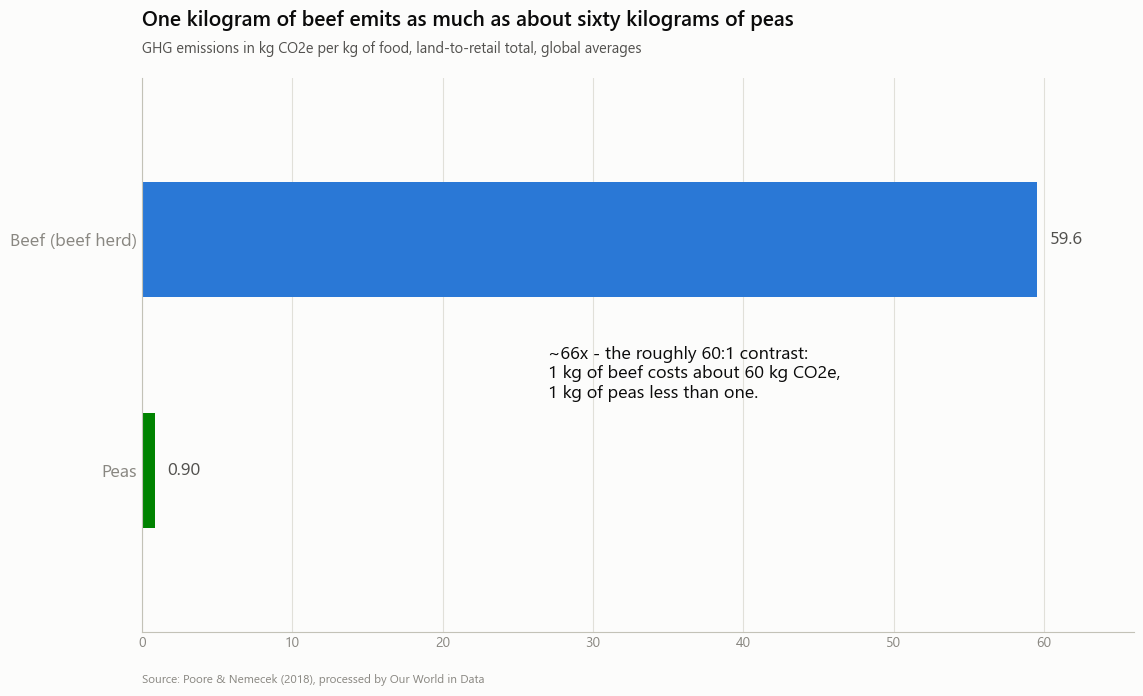

In [4]:
beef = perkg.loc[perkg['Food product'] == 'Beef (beef herd)', STAGE_TOTAL].iloc[0]
peas = perkg.loc[perkg['Food product'] == 'Peas', STAGE_TOTAL].iloc[0]
ratio = beef / peas

beef_avg = perkg.loc[perkg['Food product'] == 'Beef (beef herd)', OWID_PERKG].iloc[0]
peas_avg = perkg.loc[perkg['Food product'] == 'Peas', OWID_PERKG].iloc[0]
ratio_avg = beef_avg / peas_avg

print(f'STAGE_TOTAL basis: beef {beef:.2f} vs peas {peas:.3f} kg CO2e/kg -> {ratio:.1f}x')
print(f'OWID_PERKG companion series: beef {beef_avg:.2f} vs peas {peas_avg:.2f} -> {ratio_avg:.1f}x')

fig, ax = plt.subplots(figsize=(12.8, 7.2))
foods = ['Peas', 'Beef (beef herd)']          # beef ends up on top
vals = [peas, beef]
ax.barh(foods, vals, height=0.5, color=[GREEN, BLUE])

for y, v in enumerate(vals):
    ax.text(v + 0.8, y, fmt(v), va='center', ha='left', fontsize=13, color=SEC)

ax.annotate('~66x - the roughly 60:1 contrast:\n'
            '1 kg of beef costs about 60 kg CO2e,\n'
            '1 kg of peas less than one.',
            xy=(27, 0.42), fontsize=13, color=INK, ha='left', va='center')

style_axes(ax)
ax.set_xlim(0, 66)
ax.set_xticks(range(0, 70, 10))
ax.set_ylim(-0.7, 1.7)
ax.tick_params(axis='y', labelsize=13)

add_titles(ax,
           'One kilogram of beef emits as much as about sixty kilograms of peas',
           'GHG emissions in kg CO2e per kg of food, land-to-retail total, global averages',
           'Source: Poore & Nemecek (2018), processed by Our World in Data',
           source_pts=-30)

fig.savefig(FIGS / 'fig_slide02_beef_vs_peas.png',
            dpi=200, bbox_inches='tight', facecolor=SURFACE)
plt.show()

**Takeaway.** On the land-to-retail basis (`STAGE_TOTAL`), Beef (beef herd) emits
**59.57 kg CO2e per kg** against **0.896** for Peas - a ratio of **66.5x**, the
"roughly 60:1" contrast the deck opens with. Put differently: producing a single
kilogram of beef emits about as much as sixty kilograms of peas.

*Footnote:* the source file also carries a second total, `OWID_PERKG` ("Total Global
Average GHG Emissions per kg"), on which beef is 99.48 vs 0.98 for peas - a ratio of
about **101:1** (computed above from the loaded file). The repository does not document
the exact scope difference between the two totals, so we keep them strictly separate:
`STAGE_TOTAL` whenever the seven stage columns are in play, `OWID_PERKG` only as a
companion global-average per-kg series.

## Slide 4 - the per-kg spread: 16 selected foods

The hook generalizes: ranking foods by the land-to-retail total (`STAGE_TOTAL`) shows
how wide the per-kg spread is and where the animal/plant line runs. A 43-bar chart is
not legible on a projected slide, so the deck figure shows **16 selected foods**:

- the **seven highest emitters** on `STAGE_TOTAL` - Beef (beef herd), Lamb & Mutton,
  Cheese, Beef (dairy herd), Dark Chocolate, Coffee, Shrimps (farmed) - selected by
  rank and asserted in code;
- **five widely eaten mid-range staples** - Pig Meat, Poultry Meat, Fish (farmed),
  Eggs, Rice;
- **four low-emission staples** - Milk, Tofu, Peas, Nuts - chosen so the selection
  spans the middle and bottom of the range with foods the deck's dietary argument
  discusses.

The full 43-food ranking follows as an appendix figure.

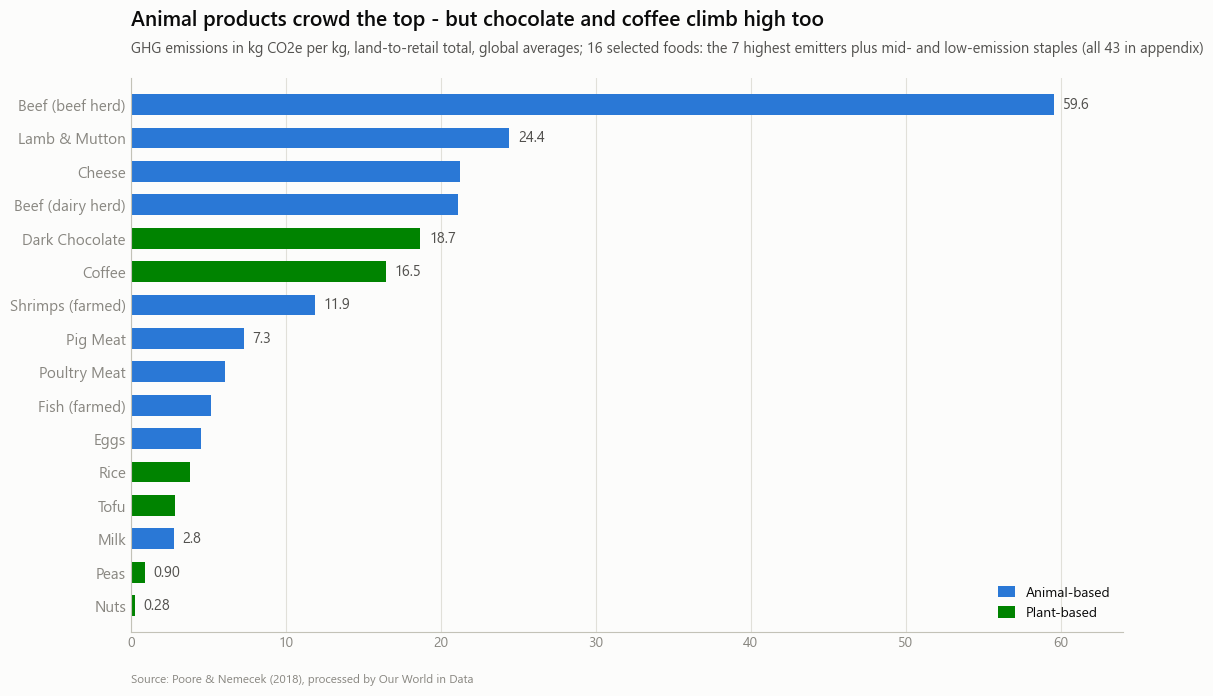

     Food product     Category  Total from Land to Retail
 Beef (beef herd) Animal-based                     59.570
    Lamb & Mutton Animal-based                     24.415
           Cheese Animal-based                     21.240
Beef (dairy herd) Animal-based                     21.085
   Dark Chocolate  Plant-based                     18.681
           Coffee  Plant-based                     16.477
 Shrimps (farmed) Animal-based                     11.854
         Pig Meat Animal-based                      7.282
     Poultry Meat Animal-based                      6.092
    Fish (farmed) Animal-based                      5.183
             Eggs Animal-based                      4.507
             Rice  Plant-based                      3.839
             Tofu  Plant-based                      2.871
             Milk Animal-based                      2.781
             Peas  Plant-based                      0.896
             Nuts  Plant-based                      0.278


In [5]:
# 16 selected foods: the top-7 emitters on STAGE_TOTAL (asserted below), plus widely
# eaten mid-range staples and low-emission staples from the deck's dietary story.
KEY_FOODS = ['Beef (beef herd)', 'Lamb & Mutton', 'Cheese', 'Beef (dairy herd)',
             'Dark Chocolate', 'Coffee', 'Shrimps (farmed)',                # top-7 emitters
             'Pig Meat', 'Poultry Meat', 'Fish (farmed)', 'Eggs', 'Rice',   # mid-range staples
             'Milk', 'Tofu', 'Peas', 'Nuts']                                # low-emission staples

top7 = list(perkg.sort_values(STAGE_TOTAL, ascending=False).head(7)['Food product'])
assert set(top7) == set(KEY_FOODS[:7]), 'first seven KEY_FOODS must be the top-7 emitters'

k = (perkg[perkg['Food product'].isin(KEY_FOODS)]
     .sort_values(STAGE_TOTAL, ascending=True).reset_index(drop=True))  # largest ends on top
assert len(k) == 16, f'expected 16 selected foods, got {len(k)}'
colors = [BLUE if f in ANIMAL else GREEN for f in k['Food product']]

LABEL4 = {'Beef (beef herd)', 'Lamb & Mutton', 'Dark Chocolate', 'Coffee',
          'Shrimps (farmed)', 'Pig Meat', 'Milk', 'Peas', 'Nuts'}

fig, ax = plt.subplots(figsize=(12.8, 7.2))
ax.barh(k['Food product'], k[STAGE_TOTAL], height=0.62, color=colors)

for y, (f, v) in enumerate(zip(k['Food product'], k[STAGE_TOTAL])):
    if f in LABEL4:
        ax.text(v + 0.55, y, fmt(v), va='center', ha='left', fontsize=10.5, color=SEC)

style_axes(ax)
ax.set_xlim(0, 64)
ax.set_xticks(range(0, 70, 10))
ax.set_ylim(-0.8, len(k) - 0.2)
ax.tick_params(axis='y', labelsize=11)
cat_legend(ax, loc='lower right')

add_titles(ax,
           'Animal products crowd the top - but chocolate and coffee climb high too',
           'GHG emissions in kg CO2e per kg, land-to-retail total, global averages; 16 selected '
           'foods: the 7 highest emitters plus mid- and low-emission staples (all 43 in appendix)',
           'Source: Poore & Nemecek (2018), processed by Our World in Data',
           source_pts=-30)

fig.savefig(FIGS / 'fig_slide04_perkg_key_foods.png',
            dpi=200, bbox_inches='tight', facecolor=SURFACE)
plt.show()

print(k.sort_values(STAGE_TOTAL, ascending=False)[
    ['Food product', 'Category', STAGE_TOTAL]].to_string(index=False))

**Takeaway.** The top of the chart is dominated by animal products - Beef (beef herd)
59.57, Lamb & Mutton 24.4, Cheese 21.2, Beef (dairy herd) 21.1 kg CO2e per kg. **But
the next two places are plants:** Dark Chocolate (18.7) and Coffee (16.5) sit above
Shrimps, Pig Meat and Poultry Meat, with a large land-use-change contribution in the
source data behind both. The animal/plant split is real but not the whole story - this
is exactly the tension the clustering notebook picks up later in the deck, where
emission *profiles* rather than totals group the foods.

Across all 43 foods (appendix figure below) the spread is enormous: from Nuts at
**0.278** to beef at **59.57** kg CO2e per kg - a factor of **214x** between the least
and most emitting food.

### Appendix - the full 43-food ranking

The appendix figure ranks every food in the file on `STAGE_TOTAL`, as backup for the
16-food deck figure above.

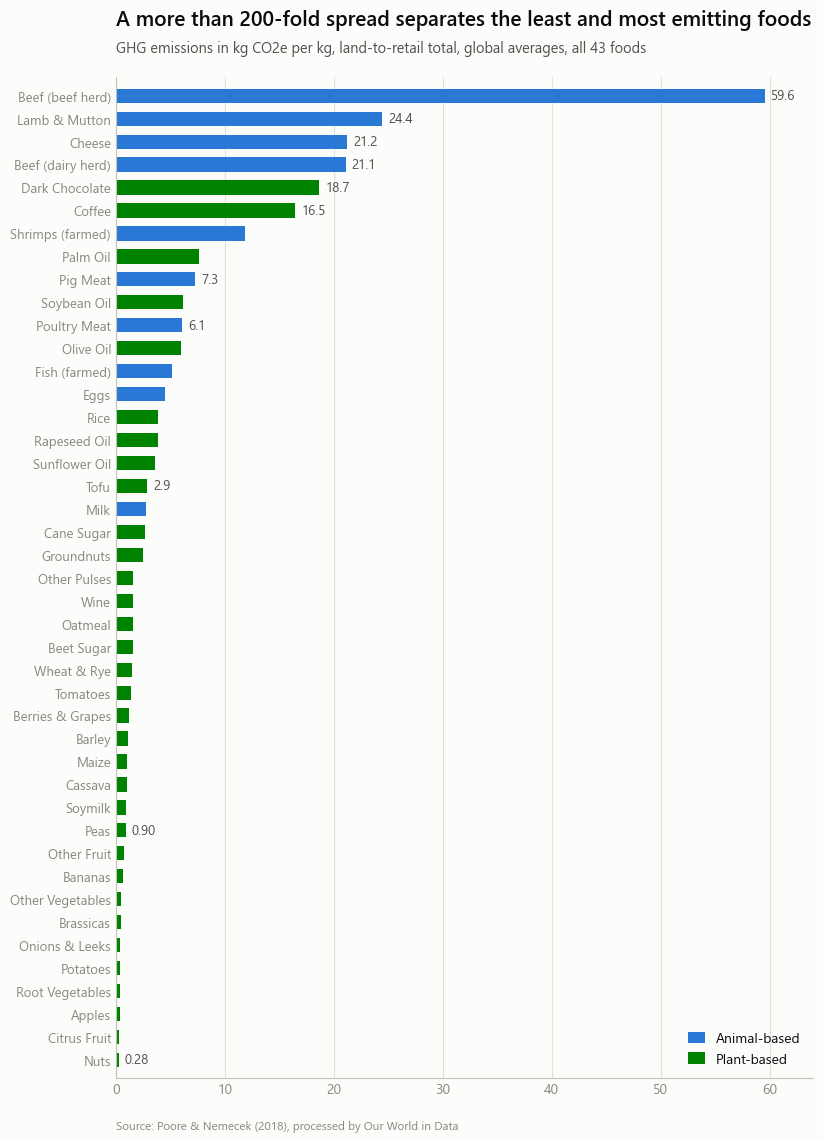

Spread: Nuts 0.278 to Beef (beef herd) 59.57 kg CO2e/kg -> 214x


In [6]:
d = perkg.sort_values(STAGE_TOTAL, ascending=True).reset_index(drop=True)  # largest ends on top
colors = [BLUE if f in ANIMAL else GREEN for f in d['Food product']]

STORY4 = {'Beef (beef herd)', 'Lamb & Mutton', 'Cheese', 'Beef (dairy herd)',
          'Dark Chocolate', 'Coffee', 'Poultry Meat', 'Pig Meat', 'Tofu',
          'Peas', 'Nuts'}

fig, ax = plt.subplots(figsize=(9, 13))
ax.barh(d['Food product'], d[STAGE_TOTAL], height=0.62, color=colors)

for y, (f, v) in enumerate(zip(d['Food product'], d[STAGE_TOTAL])):
    if f in STORY4:
        ax.text(v + 0.55, y, fmt(v), va='center', ha='left', fontsize=9.5, color=SEC)

style_axes(ax)
ax.set_xlim(0, 64)
ax.set_xticks(range(0, 70, 10))
ax.set_ylim(-0.8, len(d) - 0.2)
ax.tick_params(axis='y', labelsize=9.5)
cat_legend(ax, loc='lower right')

add_titles(ax,
           'A more than 200-fold spread separates the least and most emitting foods',
           'GHG emissions in kg CO2e per kg, land-to-retail total, global averages, all 43 foods',
           'Source: Poore & Nemecek (2018), processed by Our World in Data',
           source_pts=-30)

fig.savefig(FIGS / 'fig_appendix_perkg_all43.png',
            dpi=200, bbox_inches='tight', facecolor=SURFACE)
plt.show()

spread = d[STAGE_TOTAL].max() / d[STAGE_TOTAL].min()
lo = d.iloc[0]; hi = d.iloc[-1]
print(f"Spread: {lo['Food product']} {lo[STAGE_TOTAL]:.3f} to {hi['Food product']} "
      f"{hi[STAGE_TOTAL]:.2f} kg CO2e/kg -> {spread:.0f}x")

## Slide 5 - a different functional unit: emissions per 100 g of protein

Per-kg comparisons treat a kilogram of any food as equivalent, which flatters watery,
low-nutrition foods and penalizes nutrient-dense ones. Since the deck's dietary
argument is about *protein* sources, slide 5 re-bases the comparison on
**kg CO2e per 100 g of protein** (Poore & Nemecek, reference year 2010) - a
protein-normalized comparison, i.e. a different functional unit rather than a
correction of the per-kg one.

**Filter rule.** We keep only genuine protein sources - foods eaten primarily for
protein or contributing meaningful protein to diets: the ten animal products plus Tofu,
Peas, Other Pulses, Groundnuts, Nuts, Grains, Wheat & Rye, Oatmeal, Maize and Rice
(20 foods). Without this filter the metric produces artifacts: **Dark Chocolate reads
93.3 kg CO2e per 100 g protein - the worst of ALL foods** - purely because chocolate
contains almost no protein, so the denominator collapses. The same artifact puts
Coffee at 35.7 and Tomatoes at 19.0. Nobody eats chocolate, coffee or tomatoes for
protein, so ranking them on a per-protein basis is meaningless; we report these numbers
as an appendix note instead (printed below the chart).

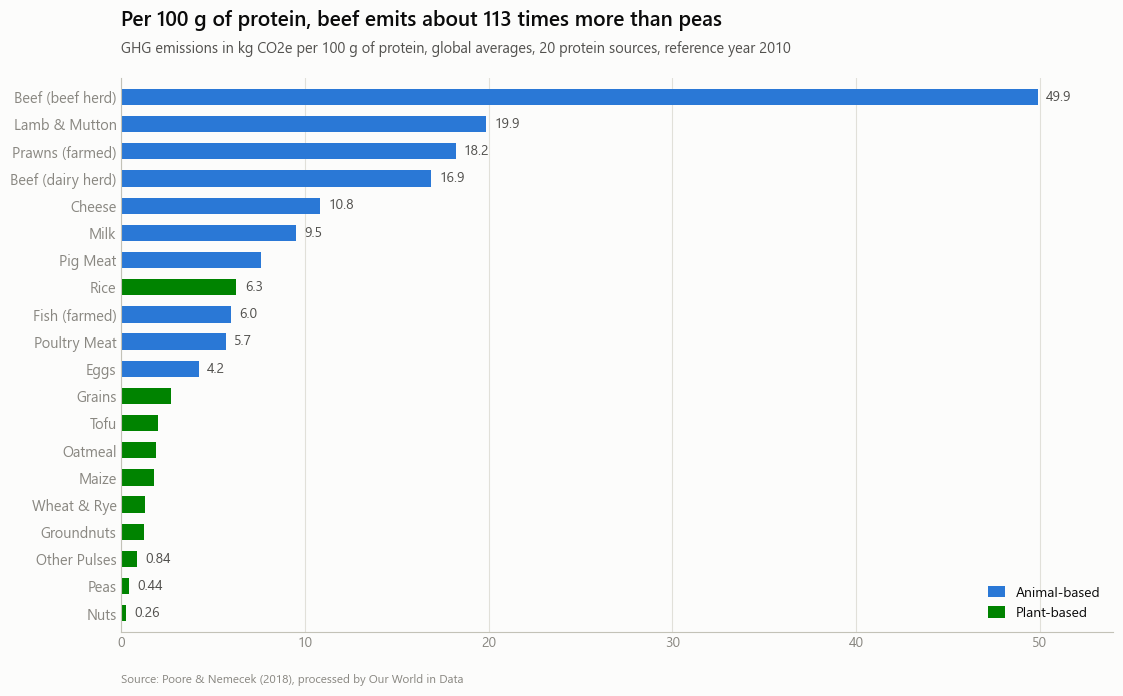

Per-protein beef:peas ratio = 49.9 / 0.44 = 113x

Appendix - the artifact the filter avoids (excluded foods, worst first):
          Entity  Greenhouse gas emissions per 100g protein
  Dark Chocolate                                  93.300000
          Coffee                                  35.662500
        Tomatoes                                  19.000000
Berries & Grapes                                  15.300000
         Cassava                                  14.666667


In [7]:
prot = pd.read_csv(DATA / 'ghg-per-protein-poore.csv')
PCOL = 'Greenhouse gas emissions per 100g protein'

PROTEIN_FOODS = ['Beef (beef herd)', 'Beef (dairy herd)', 'Lamb & Mutton', 'Pig Meat',
                 'Poultry Meat', 'Fish (farmed)', 'Prawns (farmed)', 'Eggs', 'Milk',
                 'Cheese', 'Tofu', 'Peas', 'Other Pulses', 'Groundnuts', 'Nuts',
                 'Grains', 'Wheat & Rye', 'Oatmeal', 'Maize', 'Rice']

pf = prot[prot['Entity'].isin(PROTEIN_FOODS)].copy()
assert len(pf) == 20, f'expected 20 protein sources, got {len(pf)}'

# 'Prawns (farmed)' is the per-protein file's name for 'Shrimps (farmed)' - animal-based.
ANIMAL_P = ANIMAL | {'Prawns (farmed)'}
pf['Category'] = np.where(pf['Entity'].isin(ANIMAL_P), 'Animal-based', 'Plant-based')

pf = pf.sort_values(PCOL, ascending=True).reset_index(drop=True)  # largest ends on top
colors = [BLUE if c == 'Animal-based' else GREEN for c in pf['Category']]

b = pf.loc[pf['Entity'] == 'Beef (beef herd)', PCOL].iloc[0]
p = pf.loc[pf['Entity'] == 'Peas', PCOL].iloc[0]
ratio_prot = b / p

STORY5 = {'Beef (beef herd)', 'Lamb & Mutton', 'Prawns (farmed)', 'Beef (dairy herd)',
          'Cheese', 'Milk', 'Rice', 'Poultry Meat', 'Fish (farmed)', 'Eggs',
          'Other Pulses', 'Peas', 'Nuts'}

fig, ax = plt.subplots(figsize=(12.8, 7.2))
ax.barh(pf['Entity'], pf[PCOL], height=0.6, color=colors)

for y, (f, v) in enumerate(zip(pf['Entity'], pf[PCOL])):
    if f in STORY5:
        ax.text(v + 0.45, y, fmt(v), va='center', ha='left', fontsize=10, color=SEC)

style_axes(ax)
ax.set_xlim(0, 54)
ax.set_xticks(range(0, 60, 10))
ax.set_ylim(-0.7, len(pf) - 0.3)
ax.tick_params(axis='y', labelsize=10.5)
cat_legend(ax, loc='lower right')

add_titles(ax,
           f'Per 100 g of protein, beef emits about {ratio_prot:.0f} times more than peas',
           'GHG emissions in kg CO2e per 100 g of protein, global averages, '
           '20 protein sources, reference year 2010',
           'Source: Poore & Nemecek (2018), processed by Our World in Data',
           source_pts=-30)

fig.savefig(FIGS / 'fig_slide05_per_protein.png',
            dpi=200, bbox_inches='tight', facecolor=SURFACE)
plt.show()

print(f'Per-protein beef:peas ratio = {b:.1f} / {p:.2f} = {ratio_prot:.0f}x')

print('\nAppendix - the artifact the filter avoids (excluded foods, worst first):')
excl = prot[~prot['Entity'].isin(PROTEIN_FOODS)].sort_values(PCOL, ascending=False)
print(excl[['Entity', PCOL]].head(5).to_string(index=False))

**Takeaway.** The protein-normalized comparison makes beef look *worse*, not better.
Per 100 g of protein, Beef (beef herd) emits **49.9 kg CO2e** against **0.44** for
Peas - a ratio of about **113:1** (computed above). That is steeper than the 66:1
land-to-retail per-kg contrast, but the two ratios sit on different source series as
well as different functional units: the companion global-average per-kg series
(`OWID_PERKG`) already puts beef:peas at about 101:1, so the widening from ~66:1 to
~113:1 reflects both the change of series and the change of functional unit - not
protein normalization alone.

The animal block still owns the top: lamb 19.9, prawns 18.2, beef (dairy herd) 16.9,
cheese 10.8, milk 9.5. The cheapest proteins are plants - nuts 0.26, peas 0.44,
pulses 0.84 - while the best animal options (eggs 4.2, poultry 5.7, fish 6.0) land
mid-table. Rice, at 6.3, is the one plant staple that ranks *worse* than poultry and
farmed fish on this basis - protein-poor grains pay a penalty when protein is the
yardstick.

### Appendix - the rank flip: what moves when the functional unit changes

To show *which* foods move when the functional unit changes, we compare two rankings
built from the same OWID global-average source: on the **left**, foods ranked on
`OWID_PERKG` (the global-average kg CO2e per kg series); on the **right**, foods
ranked on kg CO2e per 100 g of protein. Both sides are global-average series from the
same underlying study, so the change between the columns is the functional unit.

We join the two files on food name ("Prawns (farmed)" in the per-protein file maps to
"Shrimps (farmed)" in the per-kg file; "Grains" has no per-kg counterpart, so it drops
out of the join but stays in the main chart above). Ranks run from 1 = highest
emissions, using tie-safe `rank(method="min")`.

Joined foods: 19 (expected 19)


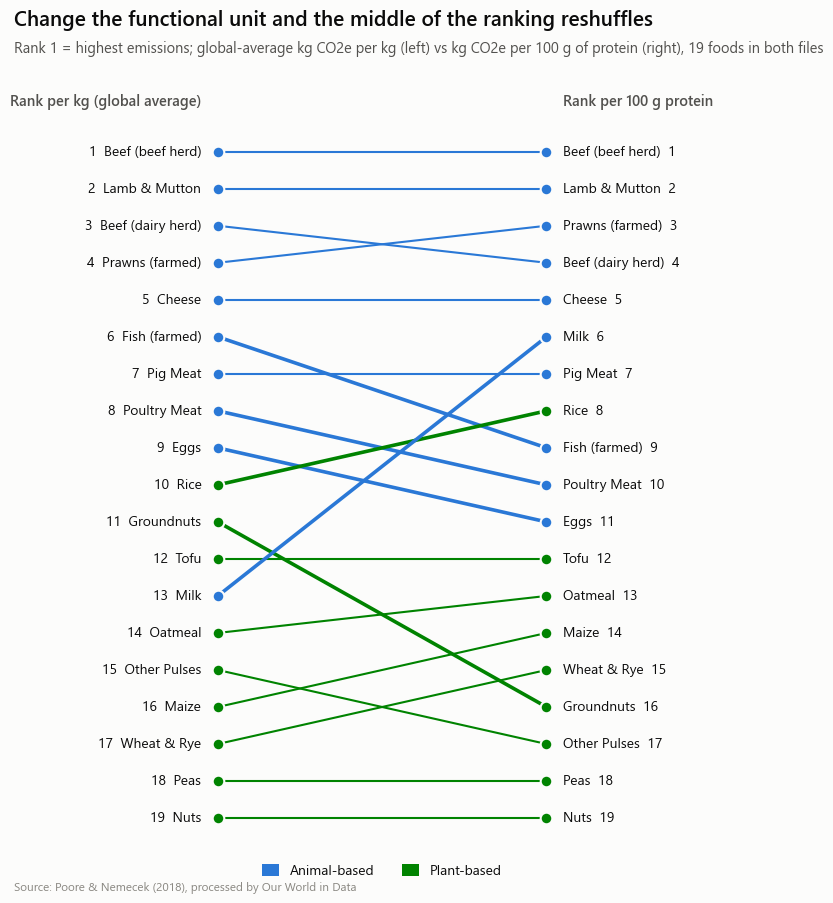

           Entity  rank_owid  rank_prot  shift
       Groundnuts         11         16     -5
    Fish (farmed)          6          9     -3
             Eggs          9         11     -2
     Other Pulses         15         17     -2
     Poultry Meat          8         10     -2
Beef (dairy herd)          3          4     -1
             Peas         18         18      0
             Nuts         19         19      0
           Cheese          5          5      0
         Pig Meat          7          7      0
             Tofu         12         12      0
    Lamb & Mutton          2          2      0
 Beef (beef herd)          1          1      0
  Prawns (farmed)          4          3      1
          Oatmeal         14         13      1
      Wheat & Rye         17         15      2
            Maize         16         14      2
             Rice         10          8      2
             Milk         13          6      7


In [8]:
name_map = {'Prawns (farmed)': 'Shrimps (farmed)'}

j = pf[pf['Entity'] != 'Grains'].copy()           # Grains: per-protein file only
j['perkg_name'] = j['Entity'].replace(name_map)
j = j.merge(perkg[['Food product', OWID_PERKG]], left_on='perkg_name', right_on='Food product')

# (d) join-count check: compute it, print it, then assert against the constant.
EXPECTED_JOIN = 19   # verified against the data: 20 protein sources minus 'Grains'
join_count = len(j)
print(f'Joined foods: {join_count} (expected {EXPECTED_JOIN})')
assert join_count == EXPECTED_JOIN, f'expected {EXPECTED_JOIN} joined foods, got {join_count}'

# Tie-safe ranks, 1 = highest emissions on each measure.
j['rank_owid'] = j[OWID_PERKG].rank(ascending=False, method='min').astype(int)
j['rank_prot'] = j[PCOL].rank(ascending=False, method='min').astype(int)

FLIPS = {'Milk', 'Groundnuts', 'Rice', 'Fish (farmed)', 'Poultry Meat', 'Eggs'}

fig, ax = plt.subplots(figsize=(9.5, 10))
for _, r in j.iterrows():
    c = BLUE if r['Category'] == 'Animal-based' else GREEN
    lw = 2.6 if r['Entity'] in FLIPS else 1.5
    ax.plot([0, 1], [r['rank_owid'], r['rank_prot']], color=c, lw=lw, zorder=2)
    ax.scatter([0, 1], [r['rank_owid'], r['rank_prot']], s=70, color=c,
               edgecolor=SURFACE, linewidth=1.5, zorder=3)
    ax.text(-0.05, r['rank_owid'], f"{r['rank_owid']}  {r['Entity']}",
            ha='right', va='center', fontsize=10, color=INK)
    ax.text(1.05, r['rank_prot'], f"{r['Entity']}  {r['rank_prot']}",
            ha='left', va='center', fontsize=10, color=INK)

ax.text(-0.05, -0.35, 'Rank per kg (global average)', ha='right', va='center',
        fontsize=10.5, color=SEC, fontweight=600)
ax.text(1.05, -0.35, 'Rank per 100 g protein', ha='left', va='center',
        fontsize=10.5, color=SEC, fontweight=600)

ax.set_xlim(-0.62, 1.62)
ax.set_ylim(19.8, -1.0)                     # rank 1 on top
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)

handles = [Patch(facecolor=BLUE, label='Animal-based'),
           Patch(facecolor=GREEN, label='Plant-based')]
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.005),
          ncols=2, fontsize=10, labelcolor=INK, handlelength=1.2, handleheight=0.9)

add_titles(ax,
           'Change the functional unit and the middle of the ranking reshuffles',
           'Rank 1 = highest emissions; global-average kg CO2e per kg (left) vs '
           'kg CO2e per 100 g of protein (right), 19 foods in both files',
           'Source: Poore & Nemecek (2018), processed by Our World in Data',
           source_pts=-24)

fig.savefig(FIGS / 'fig_appendix_slide05_rank_flip.png',
            dpi=200, bbox_inches='tight', facecolor=SURFACE)
plt.show()

moves = j[['Entity', 'rank_owid', 'rank_prot']].copy()
moves['shift'] = moves['rank_owid'] - moves['rank_prot']   # + means worse per protein
print(moves.sort_values('shift')[['Entity', 'rank_owid', 'rank_prot', 'shift']]
      .to_string(index=False))

**Takeaway.** The extremes are anchored: Beef (beef herd) and Lamb & Mutton hold
ranks 1 and 2 on both sides, and Peas (18th) and Nuts (19th) hold the bottom on both
sides. What the change of functional unit reshuffles is the **middle** of the ranking:

- **Milk makes the largest move**, from 13th on the global-average per-kg series to
  6th per 100 g of protein: milk carries relatively little protein per kg, so
  protein-normalizing works against it.
- **Groundnuts move the other way**, 11th -> 16th, and Other Pulses 15th -> 17th:
  protein-dense plants improve when protein is the yardstick.
- **Rice climbs from 10th to 8th**, moving above farmed fish (6th -> 9th) and poultry
  (8th -> 10th): a protein-poor staple pays a penalty on this basis.
- **Eggs improve from 9th to 11th**, not on their own merits but because Milk
  (13th -> 6th) and Rice (10th -> 8th) climb past them when protein is the yardstick.

The ordering of the extremes is unit-proof - ruminant meat at the top, pulses and nuts
at the bottom, on either yardstick - and it is the middle that the functional unit
reshuffles.

## Limitations

- **Global averages.** Every number is a global mean across thousands of farms;
  regional and producer-level variation is large (the original study reports wide
  percentile ranges). A specific beef supply chain can sit far from 59.57.
- **Sample size.** The per-kg file covers 43 foods, the per-protein file 32; they are
  aggregate commodity categories, not individual products.
- **Reference year.** The per-protein figures carry a 2010 reference year; production
  practices have shifted since.
- **Two totals in the per-kg file.** The source file provides both `STAGE_TOTAL`
  ("Total from Land to Retail", the exact sum of the seven stage columns) and
  `OWID_PERKG` ("Total Global Average GHG Emissions per kg"); the repository does not
  document the exact scope difference between them. We use `STAGE_TOTAL` wherever the
  stage columns are analyzed and `OWID_PERKG` only as a companion global-average
  series. The headline beef:peas contrast is ~66:1 on `STAGE_TOTAL` and ~101:1 on
  `OWID_PERKG` (both computed above).
- **Negative Land Use Change values** are source-specific accounting credits under
  the source methodology; we report them without attaching a causal explanation.
- **Protein filter.** The 20-food "genuine protein source" list is a judgment call;
  it is stated explicitly above so it can be challenged, and the excluded foods'
  per-protein values are printed as an appendix note.

## Sources

- Poore, J., & Nemecek, T. (2018). Reducing food's environmental impacts through
  producers and consumers. *Science*, 360(6392), 987-992.
- Our World in Data - "Environmental Impacts of Food Production" (processed versions of
  the Poore & Nemecek data): per-kg supply-chain stage emissions and GHG emissions per
  100 g of protein (reference year 2010).